# Modelo matemático de BFSK con índice de modulación

La modulación **FSK** (*Frequency Shift Keying*) representa la información digital mediante cambios de frecuencia.  
En el caso binario, llamado **BFSK**, se usan dos frecuencias:

$$
1 \rightarrow f_1
$$

$$
0 \rightarrow f_0
$$

donde normalmente:

$$
f_0 = f_c - \Delta f
$$

$$
f_1 = f_c + \Delta f
$$

Por tanto, la separación entre los dos tonos es:

$$
f_1-f_0 = 2\Delta f
$$

donde:

- $f_c$ es la frecuencia central.
- $\Delta f$ es la desviación de frecuencia.
- $f_0$ es la frecuencia asociada al bit $0$.
- $f_1$ es la frecuencia asociada al bit $1$.

Para introducir el índice de modulación de FSK se define:

$$
h = 2\Delta f T_s
$$

Como:

$$
f_1-f_0 = 2\Delta f
$$

entonces:

$$
h = (f_1-f_0)T_s
$$

Por tanto, la separación entre tonos puede escribirse como:

$$
f_1-f_0 = \frac{h}{T_s}
$$

También se puede despejar la desviación de frecuencia:

$$
\Delta f = \frac{h}{2T_s}
$$

Por tanto:

$$
f_0 = f_c - \frac{h}{2T_s}
$$

$$
f_1 = f_c + \frac{h}{2T_s}
$$

Para BFSK, si cada símbolo representa un bit, entonces:

$$
T_s = T_b
$$

donde:

- $T_s$ es el tiempo de símbolo.
- $T_b$ es el tiempo de bit.

Sea una secuencia binaria:

$$
b_k \in \{0,1\}
$$

Durante el intervalo:

$$
kT_s \leq t < (k+1)T_s
$$

la frecuencia transmitida es:

$$
f_k =
\begin{cases}
f_0, & b_k=0 \\[4pt]
f_1, & b_k=1
\end{cases}
$$

El modelo BFSK por intervalos de símbolo se escribe como:

$$
s_k(t) =
A\cos\left(2\pi f_k(t-kT_s)+\phi_0\right)
$$

para:

$$
kT_s \leq t < (k+1)T_s
$$

Aquí se usa el tiempo local:

$$
\tau = t-kT_s
$$

Por eso también puede escribirse:

$$
s_k(\tau)=A\cos(2\pi f_k \tau+\phi_0)
$$

con:

$$
0 \leq \tau < T_s
$$

Entonces, la señal completa se puede escribir como:

$$
s(t)=
\sum_{k=-\infty}^{\infty}
A\cos\left(2\pi f_k(t-kT_s)+\phi_0\right)
p(t-kT_s)
$$

donde el pulso rectangular es:

$$
p(t-kT_s)=
\begin{cases}
1, & kT_s \leq t < (k+1)T_s \\[4pt]
0, & \text{en otro caso}
\end{cases}
$$

Sustituyendo las frecuencias en función del índice de modulación:

$$
f_k =
\begin{cases}
f_c-\dfrac{h}{2T_s}, & b_k=0 \\[8pt]
f_c+\dfrac{h}{2T_s}, & b_k=1
\end{cases}
$$

Por tanto:

$$
s_k(t)=
\begin{cases}
A\cos\left[
2\pi\left(f_c-\dfrac{h}{2T_s}\right)(t-kT_s)+\phi_0
\right], & b_k=0 \\[10pt]
A\cos\left[
2\pi\left(f_c+\dfrac{h}{2T_s}\right)(t-kT_s)+\phi_0
\right], & b_k=1
\end{cases}
$$

Este modelo corresponde a la figura, porque en cada intervalo de duración $T_s$ la señal usa una frecuencia distinta:

$$
1 \rightarrow f_1
$$

$$
0 \rightarrow f_0
$$

Si $b_k=1$, la señal oscila más rápido porque usa $f_1$.  
Si $b_k=0$, la señal oscila más lento porque usa $f_0$.

En este modelo puede aparecer discontinuidad en los cambios de símbolo porque la fase se reinicia en cada intervalo. En efecto, al final del símbolo $k$ la señal vale aproximadamente:

$$
s_k((k+1)T_s^-)
=
A\cos(2\pi f_kT_s+\phi_0)
$$

pero al inicio del siguiente símbolo vale:

$$
s_{k+1}((k+1)T_s^+)
=
A\cos(\phi_0)
$$

En general:

$$
A\cos(2\pi f_kT_s+\phi_0)
\neq
A\cos(\phi_0)
$$

Por eso la señal puede tener un salto de amplitud en los cambios de símbolo.

Si se quiere evitar esa discontinuidad, se usa FSK de fase continua. En ese caso el modelo no reinicia la fase, sino que acumula la fase:

$$
s(t)=A\cos\left[
2\pi f_c t
+
\frac{\pi h}{T_s}
\int_{-\infty}^{t} a(\lambda)d\lambda
\right]
$$

donde:

$$
a(t)\in\{-1,+1\}
$$

En FSK de fase continua no hay salto de amplitud, pero sí hay cambio brusco en la frecuencia instantánea.

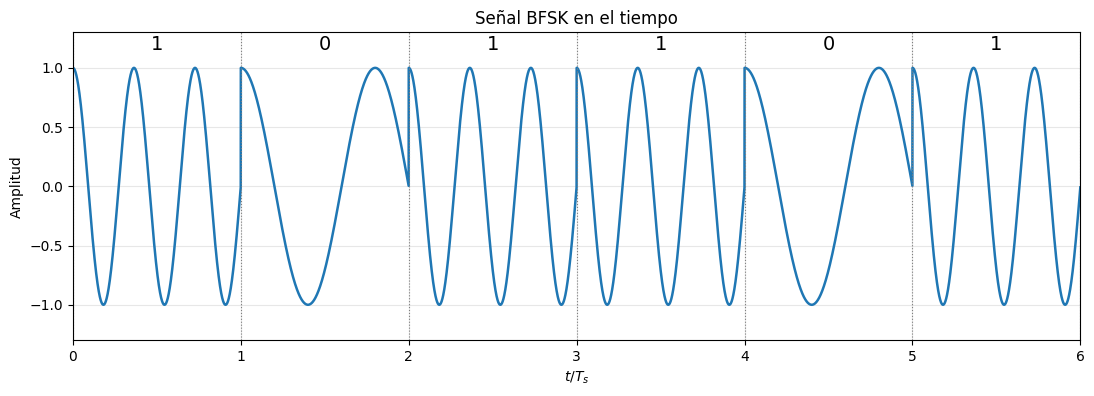

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parámetros BFSK
# ============================================================

A = 1.0                 # Amplitud
Ts = 1.0                # Tiempo de símbolo
fc = 2.0 / Ts           # Frecuencia central

h = 1.5                 # Índice de modulación
df = h / (2 * Ts)       # Desviación de frecuencia

f0 = fc - df            # Frecuencia para bit 0
f1 = fc + df            # Frecuencia para bit 1

bits = np.array([1, 0, 1, 1, 0, 1])
Nsym = len(bits)

fs = 2000
t = np.arange(0, Nsym * Ts, 1 / fs)

s = np.zeros_like(t)

phi0 = 0.0

# ============================================================
# Señal BFSK por intervalos de símbolo
# ============================================================

for k, bit in enumerate(bits):
    t_ini = k * Ts
    t_fin = (k + 1) * Ts

    idx = (t >= t_ini) & (t < t_fin)

    tau = t[idx] - t_ini

    if bit == 1:
        fk = f1
    else:
        fk = f0

    s[idx] = A * np.cos(2 * np.pi * fk * tau + phi0)

# ============================================================
# Gráfica de la señal en el tiempo
# ============================================================

plt.figure(figsize=(13, 4))

plt.plot(t / Ts, s, linewidth=1.8)

for k in range(Nsym + 1):
    plt.axvline(k, color="gray", linestyle=":", linewidth=0.8)

for k, bit in enumerate(bits):
    plt.text(k + 0.5, 1.15, str(bit), ha="center", fontsize=14)

plt.xlabel(r"$t/T_s$")
plt.ylabel("Amplitud")
plt.title("Señal BFSK en el tiempo")
plt.xlim(0, Nsym)
plt.ylim(-1.3, 1.3)
plt.grid(True, alpha=0.3)

plt.show()

# Modelo matemático de CPFSK

La modulación **CPFSK** significa:

$$
\text{Continuous Phase Frequency Shift Keying}
$$

En español:

$$
\text{FSK de fase continua}
$$

Es una versión de FSK en la cual la información digital se transmite cambiando la frecuencia de la portadora, pero imponiendo que la **fase no tenga saltos** en los cambios de símbolo.

En una FSK convencional por tramos, la señal puede escribirse como:

$$
s_k(t)=A\cos\left(2\pi f_k(t-kT_s)+\phi_0\right)
$$

para:

$$
kT_s \leq t < (k+1)T_s
$$

donde $f_k$ cambia dependiendo del bit transmitido.  
El problema de este modelo es que la fase puede reiniciarse en cada símbolo. Por eso pueden aparecer discontinuidades en la señal.

Para evitar ese problema, en CPFSK se impone que la fase sea continua.

La condición fundamental de CPFSK es:

$$
\theta((k+1)T_s^-)=\theta((k+1)T_s^+)
$$

donde:

- $\theta((k+1)T_s^-)$ es la fase justo antes del cambio de símbolo.
- $\theta((k+1)T_s^+)$ es la fase justo después del cambio de símbolo.
- $T_s$ es el tiempo de símbolo.

Esto significa que la fase no puede saltar cuando cambia el bit.

---

## Señal CPFSK general

La señal pasabanda se define como:

$$
s(t)=A\cos(\theta(t))
$$

donde:

- $A$ es la amplitud de la señal.
- $\theta(t)$ es la fase instantánea.

La frecuencia instantánea se relaciona con la fase mediante:

$$
f_i(t)=\frac{1}{2\pi}\frac{d\theta(t)}{dt}
$$

Por tanto, si conocemos la frecuencia instantánea, podemos obtener la fase integrando:

$$
\theta(t)=2\pi\int_0^t f_i(\lambda)d\lambda+\theta(0)
$$

donde:

- $f_i(t)$ es la frecuencia instantánea.
- $\theta(0)$ es la fase inicial.

En CPFSK, la frecuencia instantánea cambia según la señal digital transmitida, pero la fase se obtiene por acumulación. Por eso la fase no se reinicia.

---

## Señal digital polar

Para BFSK, la información binaria puede representarse mediante una señal polar:

$$
a_k \in \{-1,+1\}
$$

Se puede asignar:

$$
b_k=0 \rightarrow a_k=-1
$$

$$
b_k=1 \rightarrow a_k=+1
$$

donde:

- $b_k$ es el bit transmitido.
- $a_k$ es el símbolo polar asociado.

La señal digital polar en el tiempo se escribe como:

$$
a(t)=\sum_{k=-\infty}^{\infty} a_k p(t-kT_s)
$$

donde $p(t)$ es un pulso rectangular de duración $T_s$:

$$
p(t)=
\begin{cases}
1, & 0\leq t<T_s \\[4pt]
0, & \text{en otro caso}
\end{cases}
$$

Entonces, durante cada símbolo:

$$
a(t)=a_k
$$

para:

$$
kT_s \leq t < (k+1)T_s
$$

---

## Frecuencia instantánea en CPFSK

En CPFSK binaria, la frecuencia instantánea se define como:

$$
f_i(t)=f_c+\Delta f\,a(t)
$$

donde:

- $f_c$ es la frecuencia central.
- $\Delta f$ es la desviación de frecuencia.
- $a(t)$ es la señal digital polar.

Como $a(t)$ solo puede tomar los valores $-1$ y $+1$, entonces:

Si:

$$
a(t)=-1
$$

la frecuencia instantánea es:

$$
f_i(t)=f_c-\Delta f
$$

y se transmite la frecuencia:

$$
f_0=f_c-\Delta f
$$

Si:

$$
a(t)=+1
$$

la frecuencia instantánea es:

$$
f_i(t)=f_c+\Delta f
$$

y se transmite la frecuencia:

$$
f_1=f_c+\Delta f
$$

Por tanto:

$$
0 \rightarrow f_0=f_c-\Delta f
$$

$$
1 \rightarrow f_1=f_c+\Delta f
$$

La separación entre los dos tonos es:

$$
f_1-f_0=2\Delta f
$$

---

## Índice de modulación en CPFSK

El índice de modulación de FSK se define como:

$$
h=2\Delta f T_s
$$

Como:

$$
f_1-f_0=2\Delta f
$$

entonces también se puede escribir:

$$
h=(f_1-f_0)T_s
$$

De esta expresión se obtiene:

$$
f_1-f_0=\frac{h}{T_s}
$$

La desviación de frecuencia queda:

$$
\Delta f=\frac{h}{2T_s}
$$

Por tanto, las frecuencias de CPFSK se pueden escribir en función del índice de modulación:

$$
f_0=f_c-\frac{h}{2T_s}
$$

$$
f_1=f_c+\frac{h}{2T_s}
$$

El índice de modulación $h$ controla la separación entre los tonos:

- Si $h$ aumenta, $f_0$ y $f_1$ quedan más separados.
- Si $h$ disminuye, $f_0$ y $f_1$ quedan más cercanos.

---

## Fase instantánea de CPFSK

La señal CPFSK se construye acumulando la frecuencia instantánea.

Partiendo de:

$$
f_i(t)=f_c+\Delta f\,a(t)
$$

y usando:

$$
\theta(t)=2\pi\int_0^t f_i(\lambda)d\lambda+\theta(0)
$$

se obtiene:

$$
\theta(t)
=
2\pi\int_0^t
\left[
f_c+\Delta f\,a(\lambda)
\right]
d\lambda
+\theta(0)
$$

Separando los términos:

$$
\theta(t)
=
2\pi f_c t
+
2\pi\Delta f
\int_0^t a(\lambda)d\lambda
+\theta(0)
$$

Por tanto, la señal CPFSK queda:

$$
s(t)=A\cos\left[
2\pi f_c t
+
2\pi\Delta f
\int_0^t a(\lambda)d\lambda
+\theta(0)
\right]
$$

Usando:

$$
\Delta f=\frac{h}{2T_s}
$$

se obtiene:

$$
s(t)=A\cos\left[
2\pi f_c t
+
2\pi\left(\frac{h}{2T_s}\right)
\int_0^t a(\lambda)d\lambda
+\theta(0)
\right]
$$

Simplificando:

$$
s(t)=A\cos\left[
2\pi f_c t
+
\frac{\pi h}{T_s}
\int_0^t a(\lambda)d\lambda
+\theta(0)
\right]
$$

Esta es la expresión general de una señal **CPFSK binaria**.

---

## Modelo por intervalos de símbolo

Durante el intervalo:

$$
kT_s \leq t < (k+1)T_s
$$

la señal polar vale:

$$
a(t)=a_k
$$

Por tanto, la frecuencia instantánea durante ese símbolo es constante:

$$
f_k=f_c+\Delta f\,a_k
$$

o usando el índice de modulación:

$$
f_k=f_c+a_k\frac{h}{2T_s}
$$

Si $a_k=-1$:

$$
f_k=f_c-\frac{h}{2T_s}=f_0
$$

Si $a_k=+1$:

$$
f_k=f_c+\frac{h}{2T_s}=f_1
$$

La fase dentro del símbolo $k$ se puede escribir como:

$$
\theta_k(t)
=
\theta(kT_s)
+
2\pi f_k(t-kT_s)
$$

para:

$$
kT_s \leq t < (k+1)T_s
$$

Entonces, la señal CPFSK durante el símbolo $k$ es:

$$
s_k(t)
=
A\cos\left[
\theta(kT_s)
+
2\pi f_k(t-kT_s)
\right]
$$

La diferencia con FSK convencional es que $\theta(kT_s)$ no se reinicia.  
Ese valor es la fase acumulada hasta el inicio del símbolo $k$.

---

## Recursión de fase

Para garantizar continuidad de fase, la fase inicial de cada símbolo debe ser igual a la fase final del símbolo anterior.

Al final del símbolo $k$, es decir en:

$$
t=(k+1)T_s
$$

la fase vale:

$$
\theta((k+1)T_s)
=
\theta(kT_s)
+
2\pi f_k T_s
$$

Por tanto, la fase se actualiza recursivamente como:

$$
\theta_{k+1}
=
\theta_k
+
2\pi f_k T_s
$$

donde:

$$
\theta_k=\theta(kT_s)
$$

Sustituyendo:

$$
f_k=f_c+a_k\frac{h}{2T_s}
$$

se obtiene:

$$
\theta_{k+1}
=
\theta_k
+
2\pi
\left(
f_c+a_k\frac{h}{2T_s}
\right)
T_s
$$

Distribuyendo:

$$
\theta_{k+1}
=
\theta_k
+
2\pi f_c T_s
+
\pi h a_k
$$

Esta ecuación muestra cómo evoluciona la fase símbolo a símbolo.

La fase no se reinicia, sino que se acumula.

---

## Condición de continuidad de fase

En FSK por tramos con fase reiniciada se puede tener:

$$
s_k((k+1)T_s^-)
\neq
s_{k+1}((k+1)T_s^+)
$$

Eso ocurre porque cada símbolo puede iniciar con la misma fase $\phi_0$, sin tener en cuenta cómo terminó el símbolo anterior.

En CPFSK se impone:

$$
\theta_{k+1}^{\text{inicio}}
=
\theta_k^{\text{final}}
$$

Por eso:

$$
s_k((k+1)T_s^-)
=
s_{k+1}((k+1)T_s^+)
$$

Esto elimina los saltos de amplitud en la señal.

La frecuencia sí puede cambiar bruscamente de un símbolo al siguiente:

$$
f_0 \leftrightarrow f_1
$$

pero la fase no cambia de forma brusca.

---

## Relación entre CPFSK y MSK

Un caso muy importante de CPFSK es **MSK**:

$$
\text{Minimum Shift Keying}
$$

MSK ocurre cuando:

$$
h=\frac{1}{2}
$$

Como:

$$
f_1-f_0=\frac{h}{T_s}
$$

si:

$$
h=\frac{1}{2}
$$

entonces:

$$
f_1-f_0=\frac{1}{2T_s}
$$

Este valor corresponde a la mínima separación entre tonos que permite una forma eficiente de modulación de fase continua.

Por eso MSK puede interpretarse como una CPFSK con índice de modulación:

$$
h=\frac{1}{2}
$$

---

## Valores de $h$ en CPFSK

Para que una señal sea CPFSK no se exige un único valor de $h$.  
La propiedad de fase continua se obtiene imponiendo que la fase se acumule y no se reinicie.

En teoría:

$$
h>0
$$

puede usarse en CPFSK.

Sin embargo, en sistemas prácticos se suelen usar valores racionales:

$$
h=\frac{m}{p}
$$

donde $m$ y $p$ son enteros.

Ejemplos comunes son:

$$
h=\frac{1}{2}
$$

$$
h=\frac{1}{3}
$$

$$
h=\frac{2}{3}
$$

$$
h=1
$$

El caso más importante es:

$$
h=\frac{1}{2}
$$

porque corresponde a MSK.

---

## Forma final del modelo CPFSK binario

Sea:

$$
a_k\in\{-1,+1\}
$$

con:

$$
0 \rightarrow -1
$$

$$
1 \rightarrow +1
$$

La frecuencia instantánea es:

$$
f_i(t)=f_c+\frac{h}{2T_s}a(t)
$$

donde:

$$
a(t)=\sum_{k=-\infty}^{\infty}a_kp(t-kT_s)
$$

La fase instantánea es:

$$
\theta(t)
=
2\pi f_c t
+
\frac{\pi h}{T_s}
\int_0^t a(\lambda)d\lambda
+\theta(0)
$$

La señal CPFSK es:

$$
s(t)=A\cos\left[
2\pi f_c t
+
\frac{\pi h}{T_s}
\int_0^t a(\lambda)d\lambda
+\theta(0)
\right]
$$

En forma recursiva por símbolo:

$$
s_k(t)=A\cos\left[
\theta_k+
2\pi
\left(
f_c+a_k\frac{h}{2T_s}
\right)
(t-kT_s)
\right]
$$

para:

$$
kT_s \leq t < (k+1)T_s
$$

con actualización de fase:

$$
\theta_{k+1}
=
\theta_k
+
2\pi f_c T_s
+
\pi h a_k
$$

Esta recursión es la que garantiza que la fase sea continua entre símbolos.

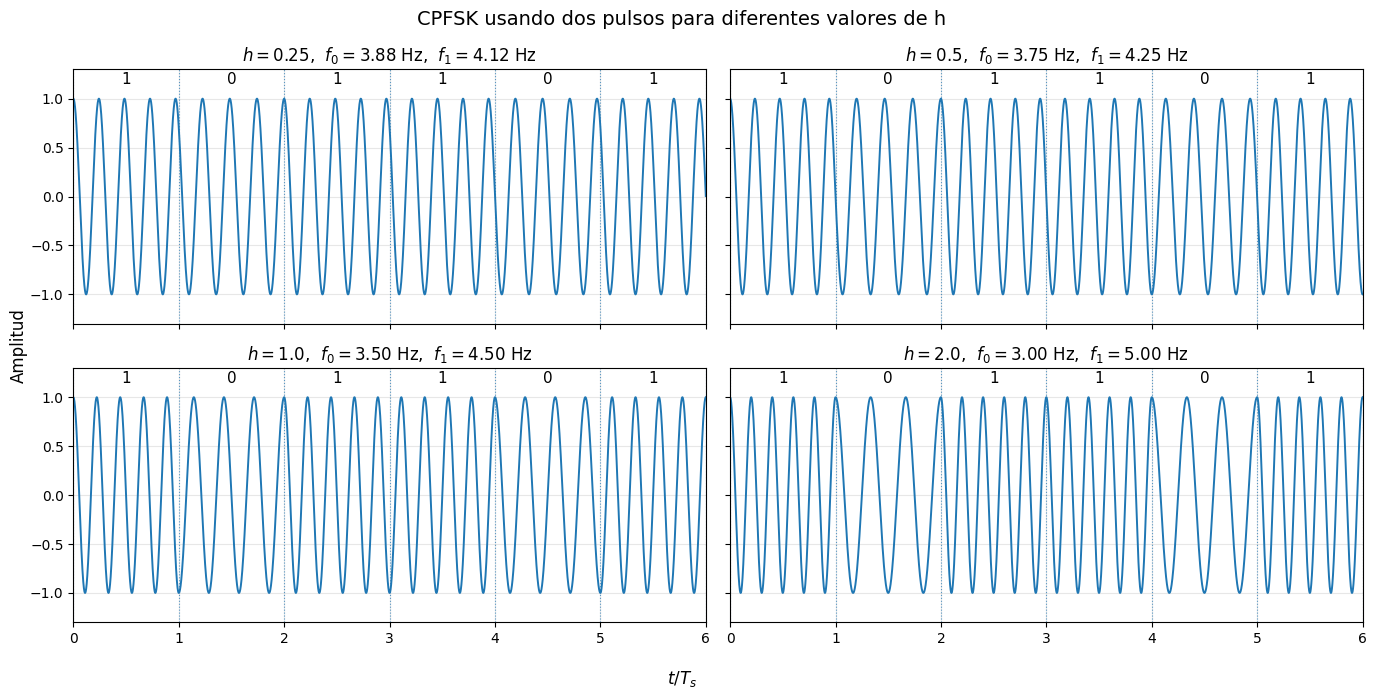

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parámetros generales
# ============================================================

A = 1.0
Ts = 1.0
fc = 4.0

bits = np.array([1, 0, 1, 1, 0, 1])
Nsym = len(bits)

fs = 5000
h_values = [0.25, 0.5, 1.0, 2.0]

# Tiempo local de un símbolo
tau = np.arange(0, Ts, 1 / fs)

# ============================================================
# Función para generar CPFSK usando dos pulsos
# ============================================================

def generar_cpfsk_dos_pulsos(bits, h, A, fc, Ts, fs):
    """
    Genera una señal CPFSK usando dos pulsos:
    
    s0(t): pulso asociado al bit 0
    s1(t): pulso asociado al bit 1
    
    La fase no se reinicia entre símbolos.
    """

    df = h / (2 * Ts)

    f0 = fc - df
    f1 = fc + df

    tau = np.arange(0, Ts, 1 / fs)

    s_total = []
    t_total = []

    theta_k = 0.0

    for k, bit in enumerate(bits):

        if bit == 0:
            fk = f0
        else:
            fk = f1

        # Pulso correspondiente al bit actual
        # No se reinicia la fase: se usa theta_k
        pulso = A * np.cos(theta_k + 2 * np.pi * fk * tau)

        # Tiempo global del símbolo
        t_symbol = k * Ts + tau

        s_total.append(pulso)
        t_total.append(t_symbol)

        # Actualización de fase para garantizar continuidad
        theta_k = theta_k + 2 * np.pi * fk * Ts

    s_total = np.concatenate(s_total)
    t_total = np.concatenate(t_total)

    return t_total, s_total, f0, f1


# ============================================================
# Gráficas en la misma imagen, pero en diferentes plots
# ============================================================

fig, axs = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)

axs = axs.flatten()

for i, h in enumerate(h_values):

    t, s, f0, f1 = generar_cpfsk_dos_pulsos(
        bits=bits,
        h=h,
        A=A,
        fc=fc,
        Ts=Ts,
        fs=fs
    )

    axs[i].plot(t / Ts, s, linewidth=1.4)

    # Límites de símbolo
    for k in range(Nsym + 1):
        axs[i].axvline(k, linestyle=":", linewidth=0.8, alpha=0.7)

    # Bits en la parte superior
    for k, bit in enumerate(bits):
        axs[i].text(k + 0.5, 1.15, str(bit), ha="center", fontsize=11)

    axs[i].set_title(
        rf"$h={h}$,  $f_0={f0:.2f}$ Hz,  $f_1={f1:.2f}$ Hz"
    )

    axs[i].set_xlim(0, Nsym)
    axs[i].set_ylim(-1.3, 1.3)
    axs[i].grid(True, alpha=0.3)

# Etiquetas comunes
fig.supxlabel(r"$t/T_s$")
fig.supylabel("Amplitud")

fig.suptitle("CPFSK usando dos pulsos para diferentes valores de h", fontsize=14)

plt.tight_layout()
plt.show()

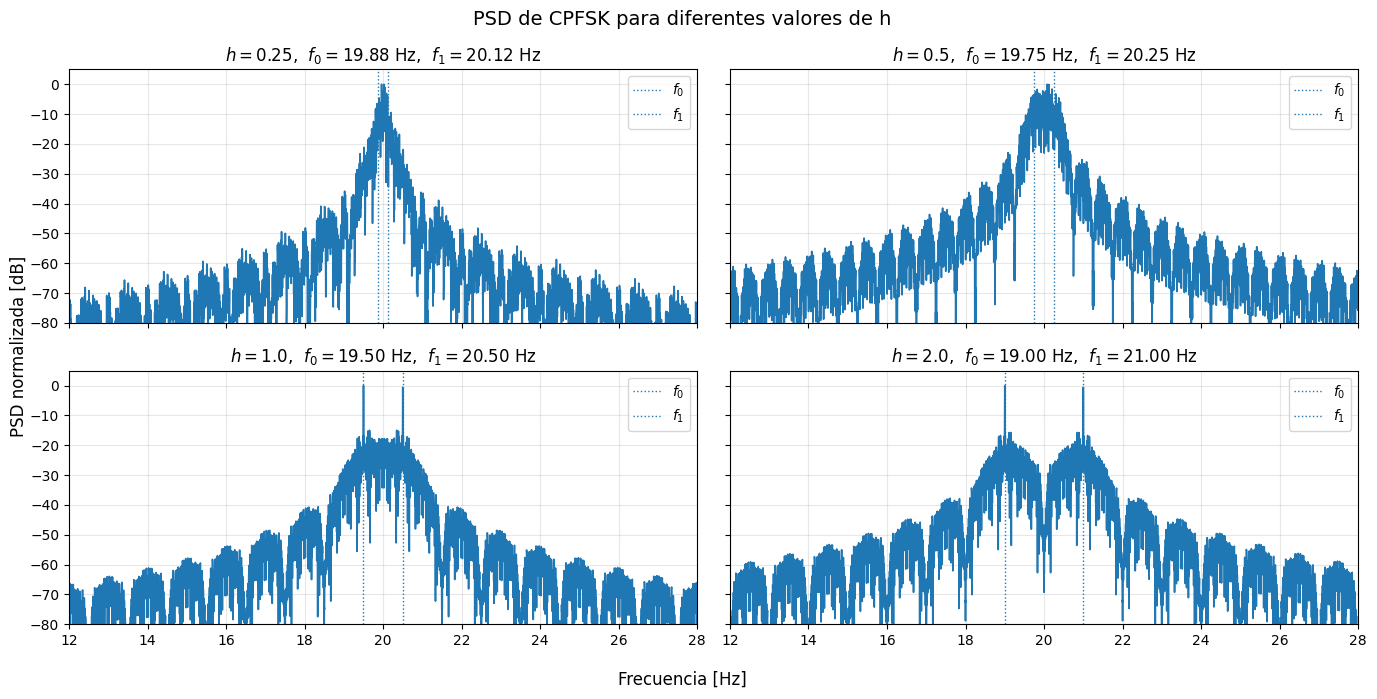

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parámetros generales
# ============================================================

A = 1.0
Ts = 1.0
fc = 20.0

fs = 2000
h_values = [0.25, 0.5, 1.0, 2.0]

# Secuencia más larga para que la PSD se vea mejor
np.random.seed(10)
Nsym = 300
bits = np.random.randint(0, 2, Nsym)

tau = np.arange(0, Ts, 1 / fs)

# ============================================================
# Función CPFSK usando dos pulsos
# ============================================================

def generar_cpfsk_dos_pulsos(bits, h, A, fc, Ts, fs):
    df = h / (2 * Ts)

    f0 = fc - df
    f1 = fc + df

    tau = np.arange(0, Ts, 1 / fs)

    s_total = []
    t_total = []

    theta_k = 0.0

    for k, bit in enumerate(bits):

        if bit == 0:
            fk = f0
        else:
            fk = f1

        pulso = A * np.cos(theta_k + 2 * np.pi * fk * tau)

        t_symbol = k * Ts + tau

        s_total.append(pulso)
        t_total.append(t_symbol)

        # Actualización de fase continua
        theta_k = theta_k + 2 * np.pi * fk * Ts

    s_total = np.concatenate(s_total)
    t_total = np.concatenate(t_total)

    return t_total, s_total, f0, f1


# ============================================================
# Función para calcular PSD
# ============================================================

def calcular_psd(s, fs):
    N = len(s)

    ventana = np.hanning(N)
    s_win = s * ventana

    S = np.fft.fftshift(np.fft.fft(s_win))
    f = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))

    psd = np.abs(S)**2
    psd = psd / np.max(psd)

    psd_db = 10 * np.log10(psd + 1e-12)

    return f, psd_db


# ============================================================
# Gráfica de PSD para diferentes valores de h
# ============================================================

fig, axs = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)

axs = axs.flatten()

for i, h in enumerate(h_values):

    t, s, f0, f1 = generar_cpfsk_dos_pulsos(
        bits=bits,
        h=h,
        A=A,
        fc=fc,
        Ts=Ts,
        fs=fs
    )

    f, psd_db = calcular_psd(s, fs)

    axs[i].plot(f, psd_db, linewidth=1.2)

    axs[i].axvline(f0, linestyle=":", linewidth=1.0, label=r"$f_0$")
    axs[i].axvline(f1, linestyle=":", linewidth=1.0, label=r"$f_1$")

    axs[i].set_title(
        rf"$h={h}$,  $f_0={f0:.2f}$ Hz,  $f_1={f1:.2f}$ Hz"
    )

    axs[i].set_xlim(fc - 8, fc + 8)
    axs[i].set_ylim(-80, 5)
    axs[i].grid(True, alpha=0.3)
    axs[i].legend()

fig.supxlabel("Frecuencia [Hz]")
fig.supylabel("PSD normalizada [dB]")
fig.suptitle("PSD de CPFSK para diferentes valores de h", fontsize=14)

plt.tight_layout()
plt.show()

# Modelo matemático de MSK como OQPSK con pulsos senoidales

La modulación **MSK** (*Minimum Shift Keying*) puede interpretarse de dos formas equivalentes:

$$
\text{MSK} = \text{CPFSK con } h=\frac{1}{2}
$$

y también como:

$$
\text{MSK} = \text{OQPSK con conformación de pulso senoidal}
$$

En esta interpretación, MSK se construye separando la secuencia binaria en dos ramas:

- Rama en fase: $I$
- Rama en cuadratura: $Q$

Cada rama se comporta como una señal tipo **BPSK**, porque sus símbolos toman valores $\pm 1$.  
Luego, ambas ramas se combinan en cuadratura como en **QPSK**, pero con una diferencia importante: la rama $Q$ está retrasada un tiempo $T_b$ respecto a la rama $I$.

Por eso el modelo se relaciona con:

$$
\text{OQPSK}
$$

donde la letra **O** significa *Offset*, es decir, desplazamiento temporal.

---

## Secuencia binaria polar

Sea una secuencia binaria:

$$
b_n \in \{0,1\}
$$

Se convierte a una secuencia polar:

$$
a_n \in \{-1,+1\}
$$

usando la asignación:

$$
b_n=0 \rightarrow a_n=-1
$$

$$
b_n=1 \rightarrow a_n=+1
$$

donde:

- $T_b$ es el tiempo de bit.
- $a_n$ es el símbolo polar asociado al bit $b_n$.

---

## Separación en ramas $I$ y $Q$

La secuencia polar se separa en dos ramas:

$$
I_k = a_{2k}
$$

$$
Q_k = a_{2k+1}
$$

La rama $I$ toma los bits pares:

$$
a_0,\ a_2,\ a_4,\dots
$$

La rama $Q$ toma los bits impares:

$$
a_1,\ a_3,\ a_5,\dots
$$

Como cada rama toma un bit cada dos intervalos de bit, el tiempo de símbolo de cada rama es:

$$
T_s = 2T_b
$$

La rama $Q$ se retrasa un tiempo $T_b$ respecto a la rama $I$.  
Esto evita que las dos ramas cambien al mismo tiempo.

---

## Pulso senoidal de MSK

En QPSK convencional se suelen usar pulsos rectangulares.  
En MSK se usan pulsos suaves de forma senoidal.

El pulso base puede definirse como:

$$
p(t)=
\begin{cases}
\sin\left(\dfrac{\pi t}{2T_b}\right), & 0\leq t < 2T_b \\[8pt]
0, & \text{en otro caso}
\end{cases}
$$

Este pulso tiene duración:

$$
2T_b
$$

La duración $2T_b$ aparece porque cada rama, $I$ y $Q$, trabaja a la mitad de la tasa de bits original.

---

## Señal de la rama $I$

La señal baseband de la rama $I$ se construye como:

$$
I(t)=\sum_{k=-\infty}^{\infty} I_k p(t-2kT_b)
$$

Sustituyendo $I_k=a_{2k}$:

$$
I(t)=\sum_{k=-\infty}^{\infty} a_{2k} p(t-2kT_b)
$$

Esta rama luego modula una portadora en fase:

$$
s_I(t)=A I(t)\cos(2\pi f_c t)
$$

donde:

- $A$ es la amplitud.
- $f_c$ es la frecuencia de portadora.
- $I(t)$ es la señal de la rama en fase.

Esta rama se puede interpretar como una BPSK filtrada con pulso senoidal.

---

## Señal de la rama $Q$

La señal baseband de la rama $Q$ se construye como:

$$
Q(t)=\sum_{k=-\infty}^{\infty} Q_k p(t-(2k+1)T_b)
$$

Sustituyendo $Q_k=a_{2k+1}$:

$$
Q(t)=\sum_{k=-\infty}^{\infty} a_{2k+1} p(t-(2k+1)T_b)
$$

El término:

$$
(2k+1)T_b
$$

muestra que la rama $Q$ está desplazada un tiempo $T_b$ respecto a la rama $I$.

La rama $Q$ modula una portadora en cuadratura:

$$
s_Q(t)=-A Q(t)\sin(2\pi f_c t)
$$

El signo negativo aparece por la forma usual de escribir la modulación en cuadratura:

$$
s(t)=I(t)\cos(2\pi f_c t)-Q(t)\sin(2\pi f_c t)
$$

---

## Señal MSK completa

La señal MSK se obtiene sumando las dos ramas:

$$
s_{\text{MSK}}(t)=s_I(t)+s_Q(t)
$$

Por tanto:

$$
s_{\text{MSK}}(t)
=
A I(t)\cos(2\pi f_c t)
-
A Q(t)\sin(2\pi f_c t)
$$

Sustituyendo $I(t)$ y $Q(t)$:

$$
s_{\text{MSK}}(t)
=
A
\left[
\sum_{k=-\infty}^{\infty} a_{2k}p(t-2kT_b)
\right]
\cos(2\pi f_c t)
$$

$$
-
A
\left[
\sum_{k=-\infty}^{\infty} a_{2k+1}p(t-(2k+1)T_b)
\right]
\sin(2\pi f_c t)
$$

Esta es la forma de MSK como **OQPSK con pulsos senoidales**.

---

## Interpretación con seno y coseno

Como la rama $Q$ está retrasada un tiempo $T_b$, los pulsos de las dos ramas se traslapan de forma complementaria.

Si se toma un intervalo local:

$$
0\leq \tau < T_b
$$

aparecen dos funciones complementarias:

$$
\cos\left(\frac{\pi \tau}{2T_b}\right)
$$

y

$$
\sin\left(\frac{\pi \tau}{2T_b}\right)
$$

Estas cumplen:

$$
\cos^2\left(\frac{\pi \tau}{2T_b}\right)
+
\sin^2\left(\frac{\pi \tau}{2T_b}\right)
=
1
$$

Esta identidad es muy importante porque explica por qué MSK mantiene envolvente constante.

En forma local, la señal puede verse como:

$$
s_{\text{MSK}}(t)
=
A
\left[
I_k
\cos\left(\frac{\pi \tau}{2T_b}\right)
\cos(2\pi f_c t)
-
Q_k
\sin\left(\frac{\pi \tau}{2T_b}\right)
\sin(2\pi f_c t)
\right]
$$

donde:

$$
0\leq \tau < T_b
$$

y:

$$
I_k,Q_k\in\{-1,+1\}
$$

La rama $I$ usa una forma cosenoidal y la rama $Q$ usa una forma senoidal.  
Por eso se dice que en MSK primero se suavizan los pulsos con seno y coseno, luego se modulan en dos ramas en cuadratura y finalmente se suman.

---

## Envolvente constante

La envolvente compleja de MSK puede escribirse como:

$$
u(t)=I(t)+jQ(t)
$$

En los intervalos donde se traslapan las ramas, las componentes tienen forma seno y coseno:

$$
I(t)=I_k\cos\left(\frac{\pi \tau}{2T_b}\right)
$$

$$
Q(t)=Q_k\sin\left(\frac{\pi \tau}{2T_b}\right)
$$

Como:

$$
I_k^2=1
$$

y:

$$
Q_k^2=1
$$

entonces la magnitud de la envolvente compleja es:

$$
|u(t)|^2
=
I^2(t)+Q^2(t)
$$

Sustituyendo:

$$
|u(t)|^2
=
I_k^2
\cos^2\left(\frac{\pi \tau}{2T_b}\right)
+
Q_k^2
\sin^2\left(\frac{\pi \tau}{2T_b}\right)
$$

Como $I_k^2=Q_k^2=1$:

$$
|u(t)|^2
=
\cos^2\left(\frac{\pi \tau}{2T_b}\right)
+
\sin^2\left(\frac{\pi \tau}{2T_b}\right)
$$

Por tanto:

$$
|u(t)|^2=1
$$

y:

$$
|u(t)|=1
$$

Esto muestra que MSK tiene envolvente constante.

---

## Relación con QPSK

En QPSK convencional, la señal también tiene la forma:

$$
s_{\text{QPSK}}(t)=I(t)\cos(2\pi f_c t)-Q(t)\sin(2\pi f_c t)
$$

Sin embargo, en QPSK las ramas $I$ y $Q$ pueden cambiar al mismo tiempo.

Eso puede producir cambios de fase grandes, incluso de:

$$
180^\circ
$$

En OQPSK, la rama $Q$ se retrasa $T_b$, de manera que $I$ y $Q$ no cambian simultáneamente.

En MSK, además de ese desplazamiento, los pulsos no son rectangulares, sino senoidales.  
Eso hace que la fase cambie de forma continua.

Por tanto:

$$
\text{QPSK}
\rightarrow
\text{OQPSK}
\rightarrow
\text{OQPSK con pulsos senoidales}
\rightarrow
\text{MSK}
$$

---

## Relación con BPSK

Cada rama individual puede verse como una BPSK porque sus símbolos son:

$$
+1
$$

o:

$$
-1
$$

La rama $I$ produce:

$$
s_I(t)=A I(t)\cos(2\pi f_c t)
$$

La rama $Q$ produce:

$$
s_Q(t)=-A Q(t)\sin(2\pi f_c t)
$$

Cada una cambia el signo de una portadora, como ocurre en BPSK.  
La diferencia es que una rama usa la portadora coseno y la otra usa la portadora seno.

Al sumarlas en cuadratura, se obtiene una señal tipo QPSK.  
Al usar offset y pulsos senoidales, esa señal se convierte en MSK.

---

## Relación con CPFSK

MSK también puede modelarse como una CPFSK con índice de modulación:

$$
h=\frac{1}{2}
$$

El modelo CPFSK general es:

$$
s(t)=A\cos\left[
2\pi f_c t+
\frac{\pi h}{T_b}
\int_0^t a(\lambda)d\lambda
+\theta(0)
\right]
$$

Para MSK:

$$
h=\frac{1}{2}
$$

Entonces:

$$
s_{\text{MSK}}(t)=A\cos\left[
2\pi f_c t+
\frac{\pi}{2T_b}
\int_0^t a(\lambda)d\lambda
+\theta(0)
\right]
$$

Durante cada bit, $a(t)$ toma un valor constante:

$$
a(t)=a_k\in\{-1,+1\}
$$

Por eso la fase cambia linealmente durante cada bit.

El cambio de fase por bit es:

$$
\Delta \theta
=
\frac{\pi}{2T_b}a_kT_b
$$

Entonces:

$$
\Delta \theta
=
\frac{\pi}{2}a_k
$$

Como:

$$
a_k\in\{-1,+1\}
$$

la fase cambia por bit:

$$
+\frac{\pi}{2}
$$

o:

$$
-\frac{\pi}{2}
$$

Es decir, en MSK la fase avanza o retrocede en pasos de $90^\circ$, pero lo hace de manera continua, sin saltos bruscos.

---

## Modelo final de MSK como OQPSK con pulsos senoidales

El modelo final queda:

$$
s_{\text{MSK}}(t)
=
A I(t)\cos(2\pi f_c t)
-
A Q(t)\sin(2\pi f_c t)
$$

con:

$$
I(t)=\sum_{k=-\infty}^{\infty} a_{2k}p(t-2kT_b)
$$

$$
Q(t)=\sum_{k=-\infty}^{\infty} a_{2k+1}p(t-(2k+1)T_b)
$$

y:

$$
p(t)=
\begin{cases}
\sin\left(\dfrac{\pi t}{2T_b}\right), & 0\leq t < 2T_b \\[8pt]
0, & \text{en otro caso}
\end{cases}
$$

Este modelo muestra que MSK se puede construir como dos ramas tipo BPSK, una en fase y otra en cuadratura, con la rama $Q$ desplazada en el tiempo y con pulsos senoidales. Al sumar ambas ramas se obtiene una señal de fase continua y envolvente constante.